# **LIBRARIES**

In [285]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns # Đẹp hơn matplotlib

# **GIỚI THIỆU DỮ LIỆU**
### **Về nguồn data**: 
- **Source**: World Development Indicators (WDI) là một nguồn dữ liệu do Ngân hàng Thế giới (World Bank) cung cấp.
- Các tập dataset được lựa chọn thông qua việc gộp các trường dữ liệu (Series) có chung Tên trường chính (ví dụ: 'Life Expectancy + (male/female/all),...'), Kiểu dữ liệu và lấy tất cả 
### **Về từng tập dataset**:
#### 1. `Life_Exp_Data.csv`: Life Expectancy (Tuổi thọ người dân)
1. Tổng quan:
- Bộ dữ liệu này cung cấp chỉ số tuổi thọ trung bình tại thời điểm sinh (life expectancy at birth) của dân số theo từng quốc gia, được phân chia theo giới tính (nam, nữ và tổng thể), từ năm 1960 → 2023.

2. Các cột chính:
- `Country Name`: Tên quốc gia
- `Country Code`: Mã quốc gia theo chuẩn ISO
- `Series Name`: Tên định danh, gồm loại:
    + Life expectancy at birth, female (years)
    + Life expectancy at birth, male (years)
    + Life expectancy at birth, total (years)
- `Series Code`: Mã chỉ số tương ứng, ví dụ:
    + SP.DYN.LE00.FE.IN (nữ)
    + SP.DYN.LE00.MA.IN (nam)
    + SP.DYN.LE00.IN (tổng thể)
- `1960 [YR1960] → 2023 [YR2023]`: Giá trị tuổi thọ theo từng năm (dạng số thực, đơn vị: năm tuổi)

3. Kiểu dữ liệu:
- Dữ liệu được lưu dưới dạng chuỗi (object) để bao gồm cả giá trị thiếu (..).
- Các giá trị tuổi thọ là số thập phân đại diện cho số năm (ví dụ: 66.213 năm).

4. Đặc điểm nổi bật:
- Gồm dữ liệu cho 268 quốc gia, mỗi quốc gia có 3 dòng tương ứng với 3 chỉ số (nam, nữ, tổng thể).
- Thời gian bao phủ từ năm 1960 đến 2023, với dữ liệu dày và đầy đủ hơn trong các năm gần đây.
- Dữ liệu tuổi thọ nữ thường cao hơn tuổi thọ nam ở hầu hết quốc gia.
---

#### 2. `Death_rate_Data.csv`: Death Rate (Tỷ lệ tử vong)
1. Tổng quan:
- Bộ dữ liệu này cung cấp thông tin liên quan đến tỷ lệ tử vong thô (crude death rate) và số lượng người tử vong theo nhóm tuổi, từ năm 1960 đến 2023, phân theo quốc gia.

2. Các cột chính:
- `Country Name`: Tên quốc gia
- `Country Code`: Mã quốc gia theo chuẩn ISO
- `Series Name`: Tên định danh, bao gồm:
    – Death rate, crude (per 1,000 people)
    – Number of deaths ages 5-9 years
    – Number of deaths ages 10-14 years
    – Number of deaths ages 15-19 years
    – Number of deaths ages 20-24 years
- `Series Code`: Mã định danh của chỉ số, ví dụ: SP.DYN.CDRT.IN, SH.DTH.0509, SH.DTH.1014,...
- `1960 [YR1960] → 2023 [YR2023]`: Giá trị số tương ứng theo từng năm (dạng số thập phân hoặc ..)

3. Kiểu dữ liệu:
- Các cột dữ liệu được lưu ở dạng chuỗi (object) do có chứa giá trị thiếu (..).
- Dữ liệu có thể là:
    + Số thực biểu thị tỷ lệ tử vong (ví dụ: 7.344)
    + Số nguyên biểu thị số ca tử vong (ví dụ: 4169)

4. Đặc điểm nổi bật
- Bao gồm dữ liệu cho 268 quốc gia, mỗi quốc gia có nhiều dòng dữ liệu, tương ứng với từng nhóm tuổi tử vong.
- Các nhóm tuổi bao phủ từ 5 đến 24 tuổi, chia theo 5 năm.
---
#### 3. `GDP_Data.csv`: GDP 
1. Tổng quan:
Bộ dữ liệu này tổng hợp nhiều chỉ số GDP liên quan đến kinh tế vĩ mô của các quốc gia từ năm 1974 đến 2023. Các chỉ số này phản ánh quy mô, tốc độ tăng trưởng và sự thay đổi của GDP theo thời gian, dưới nhiều đơn vị tính khác nhau.

2. Các cột chính:
- `Country Name`:	Tên quốc gia
- `Country Code`:	Mã quốc gia (ISO)
- `Series Name`: Tên định danh GDP, ví dụ:
    + GDP (constant 2015 US$)
    + GDP (current US$)
    + GDP deflator, v.v.
- `Series Code`: Mã định danh của chỉ số, ví dụ: NY.GDP.MKTP.KD, NY.GDP.MKTP.CD, NY.GDP.DEFL.ZS,...
- `1974 [YR1974] → 2023 [YR2023]`: Giá trị theo từng năm, thường ở dạng số thực hoặc .. nếu thiếu dữ liệu

3. Kiểu dữ liệu:
- Toàn bộ các cột đều là kiểu chuỗi (object) để tương thích với các ô thiếu dữ liệu (..).
- Dữ liệu bao gồm cả giá trị số thập phân và ký hiệu khoa học (ví dụ: 5.00575565E+15).

4. Đặc điểm nổi bật:
- Bao gồm 20 chỉ số GDP khác nhau trên 268 quốc gia.
- Mỗi quốc gia có nhiều dòng tương ứng với từng chỉ số.
- Thời gian bao phủ từ năm 1974 đến 2023.

5. Một số chỉ số thường gặp:
- GDP (constant 2015 US$) – GDP đã điều chỉnh theo lạm phát
- GDP (current US$) – GDP danh nghĩa theo USD hiện tại
- GDP deflator – chỉ số điều chỉnh giá theo từng nước

In [286]:
# Nhập dữ liệu từ các file csv
file_paths = [
    "Data/Life_Expectancy/Life_Exp_Data.csv",
    "Data/Death_rate/Death_rate_Data.csv",
    "Data/GDP/GDP_Data.csv"
]

# Đọc dữ liệu từ các file csv
life_exp_df = pd.read_csv(file_paths[0])
death_rate_df = pd.read_csv(file_paths[1])
gdp_df = pd.read_csv(file_paths[2])

# Hiển thị thông tin cũa từng tập dữ liệu
print(life_exp_df.info())
print(death_rate_df.info())
print(gdp_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 803 entries, 0 to 802
Data columns (total 68 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   800 non-null    object
 1   Country Code   798 non-null    object
 2   Series Name    798 non-null    object
 3   Series Code    798 non-null    object
 4   1960 [YR1960]  798 non-null    object
 5   1961 [YR1961]  798 non-null    object
 6   1962 [YR1962]  798 non-null    object
 7   1963 [YR1963]  798 non-null    object
 8   1964 [YR1964]  798 non-null    object
 9   1965 [YR1965]  798 non-null    object
 10  1966 [YR1966]  798 non-null    object
 11  1967 [YR1967]  798 non-null    object
 12  1968 [YR1968]  798 non-null    object
 13  1969 [YR1969]  798 non-null    object
 14  1970 [YR1970]  798 non-null    object
 15  1971 [YR1971]  798 non-null    object
 16  1972 [YR1972]  798 non-null    object
 17  1973 [YR1973]  798 non-null    object
 18  1974 [YR1974]  798 non-null   

In [287]:
# Hiển thị 5 dòng đầu của từng tập dữ liệu
print(life_exp_df.head())
print(death_rate_df.head())
print(gdp_df.head())

  Country Name Country Code                               Series Name  \
0  Afghanistan          AFG  Life expectancy at birth, female (years)   
1  Afghanistan          AFG    Life expectancy at birth, male (years)   
2  Afghanistan          AFG   Life expectancy at birth, total (years)   
3      Albania          ALB  Life expectancy at birth, female (years)   
4      Albania          ALB    Life expectancy at birth, male (years)   

         Series Code 1960 [YR1960] 1961 [YR1961] 1962 [YR1962] 1963 [YR1963]  \
0  SP.DYN.LE00.FE.IN        33.285        33.813        34.297        34.773   
1  SP.DYN.LE00.MA.IN         31.87        32.409        32.883        33.346   
2     SP.DYN.LE00.IN        32.535        33.068        33.547        34.016   
3  SP.DYN.LE00.FE.IN         57.78          58.9         59.75        60.831   
4  SP.DYN.LE00.MA.IN        51.365        52.618         53.82        55.071   

  1964 [YR1964] 1965 [YR1965]  ... 2014 [YR2014] 2015 [YR2015] 2016 [YR2016]  \


In [288]:
# Mô tả dữ liệu
print(life_exp_df.describe())
print(death_rate_df.describe())
print(gdp_df.describe())

       Country Name Country Code                               Series Name  \
count           800          798                                       798   
unique          268          266                                         3   
top     Afghanistan          AFG  Life expectancy at birth, female (years)   
freq              3            3                                       266   

              Series Code 1960 [YR1960] 1961 [YR1961] 1962 [YR1962]  \
count                 798           798           798           798   
unique                  3           737           742           741   
top     SP.DYN.LE00.FE.IN            ..            ..            ..   
freq                  266            42            39            39   

       1963 [YR1963] 1964 [YR1964] 1965 [YR1965]  ... 2014 [YR2014]  \
count            798           798           798  ...           798   
unique           737           734           743  ...           736   
top               ..            ..      

# **TIỀN XỬ LÝ**

## **Tiền xử lý chung**: vì các dataset có trùng nhiều thông tin cột nên có thể được tiền xử lý chung các bước sau
- Bỏ các cột không cần thiết cho mục đích phân tích như `Series Code`
- Chuyển định dạng dữ liệu rộng → dài (wide to long) bằng cách:
    + Giữ lại 3 cột chính: `Country Name`, `Series Name`
    + Gộp các cột năm thành 2 cột: `Year` (dạng số) và `Value` (giá trị chỉ số)
- Làm sạch cột Year: Trích xuất 4 chữ số từ tên cột (ví dụ: từ 2020 [YR2020] → 2020)
- Chuyển đổi dữ liệu Value sang kiểu số (float), các giá trị như .. sẽ tự động trở thành NaN

In [289]:
def preprocess_basic_all(df):
    # Bỏ cột 'Series Code' vì không cần thiết
    df = df.drop(columns=["Series Code", "Country Code"])
    
    # Melt dữ liệu để chuyển các cột năm thành một cột 'Year' và giá trị tương ứng thành cột 'Value'
    # id_vars: các cột giữ nguyên
    # var_name: tên cột chứa năm
    # value_name: tên cột chứa giá trị
    df_melted = df.melt(
        id_vars=["Country Name", "Series Name"],
        var_name="Year",
        value_name="Value"
    )

    # Chuyển cột 'Year' sang kiểu số nguyên bằng cách lấy 4 kí tự cuối cùng
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})").astype(int)

    # Chuyển cột 'Value' sang kiểu số (nếu trống thì thành NaN)
    df_melted["Value"] = pd.to_numeric(df_melted["Value"], errors="coerce")
    
    return df_melted

# Tiền xử lý dữ liệu chung
life_exp_long = preprocess_basic_all(life_exp_df)
death_rate_long = preprocess_basic_all(death_rate_df)
gdp_long = preprocess_basic_all(gdp_df)


In [290]:
# Đếm số giá trị thiếu của từng cột
print(life_exp_long.isnull().sum())
print(death_rate_long.isnull().sum())
print(gdp_long.isnull().sum())

Country Name     192
Series Name      320
Year               0
Value           3020
dtype: int64
Country Name      192
Series Name       320
Year                0
Value           41523
dtype: int64
Country Name      150
Series Name       250
Year                0
Value           84254
dtype: int64


### **Xử lý missing data**: vì lượng missing data trong từng dataset là khác nhau và phức tạp nên cần sử dụng nhiều phương pháp khác nhau để xử lý, nếu drop hết thì sẽ không thực tế, ảnh hưởng tới kết quả cuối cùng nhiều.

- Cách xử lý missing data đã thực hiện:
    + Nếu > 50% dữ liệu trong một năm bị thiếu → Loại bỏ cả năm đó
    + Nếu ≤ 50% dữ liệu bị thiếu → Giữ lại năm đó và sau này có thể điền bằng phương pháp toán học (như interpolation, nhóm trung bình, v.v.)

- Các giá trị bị thiếu còn lại được điền bằng chiến lược hai bước như sau:
    + Bước 1: interpolation theo Quốc gia - `Country Name` và `Series Name`: 
        + Với mỗi quốc gia và từng dòng dữ liệu (ví dụ: "GDP (current US$)"), các giá trị bị thiếu được interpolation tuyến tính theo thời gian để phản ánh xu hướng tại địa phương.
        + Phương pháp interpolation (interpolation): linear với tham số limit_direction='both'
    + Bước 2: Điền các giá trị NaN còn lại bằng giá trị trung bình của `Series-Year`, gọi là `Global Series-Year Mean`:
        + Một số nhóm có toàn bộ dữ liệu bị thiếu (ví dụ: không có dữ liệu GDP cho một quốc gia trong bất kỳ năm nào).
        + Các giá trị `NaN` còn lại này được điền bằng giá trị trung bình của tất cả các quốc gia cho cùng `Series Name` và Năm - `Year`.

> ***Đảm bảo rằng không còn điểm dữ liệu nào bị thiếu sau khi xử lý, đồng thời xu hướng global giúp duy trì tính thực tế của dữ liệu.*** 

In [291]:
# Hàm kiểm tra tỷ lệ giá trị thiếu data theo năm
def missing_ratio_by_year(df, threshold=0.5):
    missing_per_year = df.groupby("Year")["Value"].apply(lambda x: x.isna().mean())
    to_drop = missing_per_year[missing_per_year > threshold].index.tolist()
    to_keep = df[~df["Year"].isin(to_drop)] # ~: not để đỡ tốn vòng lặp
    return to_keep, to_drop, missing_per_year

# Tính tỷ lệ giá trị thiếu data theo năm
life_exp_filled, dropped_years_life, missing_ratio_life = missing_ratio_by_year(life_exp_long)
death_rate_filled, dropped_years_death, missing_ratio_death = missing_ratio_by_year(death_rate_long)
gdp_filled, dropped_years_gdp, missing_ratio_gdp = missing_ratio_by_year(gdp_long)

# Hiển thị tỷ lệ giá trị thiếu data theo năm
dropped_years_summary = {
    "Life Expectancy": dropped_years_life,
    "Death Rate": dropped_years_death,
    "GDP": dropped_years_gdp
}

dropped_years_summary

{'Life Expectancy': [2023],
 'Death Rate': [1960,
  1961,
  1962,
  1963,
  1964,
  1965,
  1966,
  1967,
  1968,
  1969,
  1970,
  1971,
  1972,
  1973,
  1974,
  1975,
  1976,
  1977,
  1978,
  1979,
  1980,
  1981,
  1982,
  1983,
  1984,
  1985,
  1986,
  1987,
  1988,
  1989,
  2023],
 'GDP': [1974,
  1975,
  1976,
  1977,
  1978,
  1979,
  1980,
  1981,
  1982,
  1983,
  1984,
  1985,
  1986,
  1987,
  1988,
  1989]}

In [292]:
# Nhìn lại dữ liệu sau khi xử lý giá trị thiếu
life_exp_filled.info()
death_rate_filled.info()
gdp_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50589 entries, 0 to 50588
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  50400 non-null  object 
 1   Series Name   50274 non-null  object 
 2   Year          50589 non-null  int32  
 3   Value         48372 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 52833 entries, 48030 to 100862
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  52734 non-null  object 
 1   Series Name   52668 non-null  object 
 2   Year          52833 non-null  int32  
 3   Value         48879 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 181050 entries, 85200 to 266249
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtyp

- Các năm đã bị loại bỏ vì thiếu quá nhiều dữ liệu:
1. Life Expectancy (`Life_Exp_Data.csv`):
> Dropped years: [2023]

2. Death Rate (`Death_rate_Data.csv`):
> Dropped years: [1960 → 1989, 2023] → do phần lớn chỉ số tử vong nhóm tuổi chỉ có dữ liệu từ 1990 trở đi

3. GDP (`GDP_Data.csv`):
> Dropped years: [1974 → 1989] → phần lớn quốc gia thiếu dữ liệu GDP trong các năm đầu

In [293]:
# Sử dụng hàm interpolate để điền giá trị thiếu dữ liệu theo xu hướng của từng quốc gia 
def fill_missing_by_country_trend(df):
    # Interpolate giá trị thiếu dữ liệu theo xu hướng của từng quốc gia
    # Sắp xếp dữ liệu theo 'Country Name', 'Series Name', 'Year'
    df = df.sort_values(by=["Country Name", "Series Name", "Year"])
    df["Value"] = df.groupby(["Country Name", "Series Name"])["Value"].transform( 
        lambda x: x.interpolate(method='linear', limit_direction='both') # theo xu hướng tuyến tính 
    )

    # Nếu còn giá trị thiếu sau khi interpolate thì điền bằng giá trị trung bình của cùng Series Name và Year
    missing_mask = df["Value"].isna()
    fill_value = df.groupby(["Series Name", "Year"])["Value"].transform("mean")
    df.loc[missing_mask, "Value"] = fill_value[missing_mask]    

    return df

# Điền giá trị thiếu dữ liệu theo xu hướng của từng quốc gia
life_exp_filled = fill_missing_by_country_trend(life_exp_filled)
death_rate_filled = fill_missing_by_country_trend(death_rate_filled)
gdp_filled = fill_missing_by_country_trend(gdp_filled)

In [294]:
# Kiểm tra lại dữ liệu sau khi điền giá trị thiếu
life_exp_filled.info()
death_rate_filled.info()
gdp_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50589 entries, 0 to 50586
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  50400 non-null  object 
 1   Series Name   50274 non-null  object 
 2   Year          50589 non-null  int32  
 3   Value         50274 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 52833 entries, 48030 to 100860
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  52734 non-null  object 
 1   Series Name   52668 non-null  object 
 2   Year          52833 non-null  int32  
 3   Value         52668 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 181050 entries, 85220 to 266247
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtyp

In [295]:
# Luu dữ liệu đã xử lý
life_exp_filled.to_csv("Data/Life_Expectancy/Life_Exp_Data_Processed.csv", index=False)
death_rate_filled.to_csv("Data/Death_rate/Death_rate_Data_Processed.csv", index=False)
gdp_filled.to_csv("Data/GDP/GDP_Data_Processed.csv", index=False)

# **PHÂN TÍCH DỮ LIỆU**

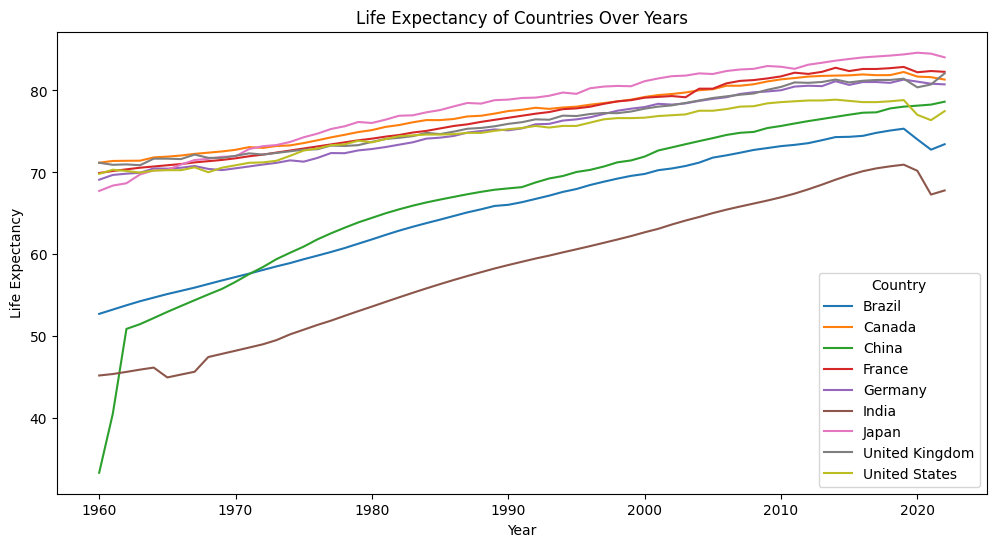

In [ ]:
# Group dữ liệu theo 'Country Name' và 'Year' để vẽ biểu đồ
life_exp_grouped = life_exp_filled.groupby(["Country Name", "Year"])["Value"].mean().reset_index()
death_rate_grouped = death_rate_filled.groupby(["Country Name", "Year"])["Value"].mean().reset_index()
gdp_grouped = gdp_filled.groupby(["Country Name", "Year"])["Value"].mean().reset_index()

relevant_country_names = ["Vietnam", "United States", "China", "Japan", "Germany", "United Kingdom", "France", "India", "Brazil", "Canada"]

# Câu 1: Vẽ biểu đồ thể hiện tuổi thọ trung bình của từng quốc gia qua các năm
plt.figure(figsize=(12, 6))
sns.lineplot(data=life_exp_grouped[life_exp_grouped["Country Name"].isin(relevant_country_names)], x="Year", y="Value", hue="Country Name")
plt.title("Life Expectancy of Countries Over Years")
plt.ylabel("Life Expectancy")
plt.legend(title="Country")
plt.show()